## CODE TAO DATA

In [24]:
import pandas as pd
from backtesting import Backtest, Strategy
import math
from vnstock3 import Vnstock
import talib as ta
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import datetime as dt

RSI_PERIOD = 14
RSI_OVERSOLD = 30
MACD_FAST = 12
MACD_SLOW = 26
MACD_SIGNAL = 9

def calculate_first_mondays(dates):
    if not isinstance(dates, pd.DatetimeIndex):
        dates = pd.DatetimeIndex(dates)
    dates_series = pd.Series(dates, index=dates)
    mondays = dates_series[dates_series.dt.dayofweek == 0]
    first_mondays = mondays.groupby([mondays.dt.year, mondays.dt.month]).first()
    return set(first_mondays)
    
class DCA(Strategy):
    average_monthly_income_vnd = 1000  # Average monthly income in VND
    investment_percentage = 0.10  # Percentage of income to invest
    fund = 0 # Initialize the investment fund 

    def init(self):
        close = self.data.Close
        # Calculate RSI
        self.rsi = self.I(ta.RSI, close, timeperiod=RSI_PERIOD) 
        # Calculate MACD
        macd, signal_line, _ = ta.MACD(close, fastperiod=MACD_FAST, slowperiod=MACD_SLOW, signalperiod=MACD_SIGNAL)  
        self.macd = self.I(pd.Series, macd)
        self.signal_line = self.I(pd.Series, signal_line)
        self.previous_macd = self.I(pd.Series(macd).shift, 1)
        self.previous_signal_line = self.I(pd.Series(signal_line).shift, 1)
        self.first_mondays = calculate_first_mondays(self.data.index)

    def next(self):
        # Update the fund at the start of each month
        today = self.data.index[-1]
        self.data.Close[-1] = self.data.Close[-1] / 10
        if today in self.first_mondays:
            self.fund += self.average_monthly_income_vnd * self.investment_percentage
            
        # Check for buy signal: RSI cross above 30 and MACD cross above Signal line
        if (self.previous_macd[-1] < self.previous_signal_line[-1] and
            self.macd[-1] >= self.signal_line[-1] and
            self.rsi[-1] > RSI_OVERSOLD):  
            share_price = self.data.Close[-1]
            max_shares_to_buy = self.fund // share_price
            lots_to_buy = max_shares_to_buy // 100
            
            if lots_to_buy > 0:
                shares_to_buy = lots_to_buy * 100
                self.buy(size=shares_to_buy)
                self.fund -= share_price * shares_to_buy
                #print(f"Buy executed at {self.data.index[-1]} with {shares_to_buy} shares at price {share_price}, total price {share_price * shares_to_buy}")


In [17]:
def run_backtest(stock_symbol, start_date, end_date):
    # Fetch stock data
    stock_data = Vnstock().stock(symbol=stock_symbol, source='VCI').quote.history(start=start_date, end=end_date)
    stock_data = stock_data.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"})
    stock_data.set_index('time', inplace=True)
    stock_data.index = pd.to_datetime(stock_data.index)
    bt = Backtest(
        stock_data,
        DCA,
        trade_on_close=True,
    )
    stats = bt.run()
    #bt.plot(filename=f'{stock_symbol}')
    # Calculate investment details
    trades = stats["_trades"]
    price_paid = trades["Size"] * trades["EntryPrice"]
    total_invested = price_paid.sum()

    current_shares = trades["Size"].sum()
    current_equity = current_shares * stock_data.Close.iloc[-1]
    return {
        'stock_symbol': stock_symbol,
        'total investment': total_invested,
        'current shares': current_shares,
        'current_equity': current_equity,
        'ror': ((current_equity - total_invested) / total_invested) * 100
    }
stock_symbols = ['FPT', 'MWG', 'E1VFVN30']
date_start = '2019-01-01'
date_end = ['2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', '2024-01-04']
dict_symbol = {}
for symbol in stock_symbols:
    for date in date_end:
        # Convert date string to datetime object to extract the year
        date_obj = datetime.strptime(date, '%Y-%m-%d')
        key = f'{symbol}_{date_obj.year}'
        # Run the backtest for each stock symbol and date range
        dict_symbol[key] = run_backtest(symbol, start_date=date_start, end_date=date)

dict_symbol

2024-10-26 17:58:55,331 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 17:58:56,412 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 17:58:57,077 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 17:58:57,576 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 17:58:58,204 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 17:58:58,776 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 17:58:59,100 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yết & giao dịch sẽ được truy xuất từ TCBS
2024-10-26 17:58:59,465 - vnstock3.common.data.data_explorer - WARNING - Thông tin niêm yế

{'FPT_2020': {'stock_symbol': 'FPT',
  'total investment': 816.9,
  'current shares': 400,
  'current_equity': 994.0000000000001,
  'ror': 21.6795201371037},
 'FPT_2021': {'stock_symbol': 'FPT',
  'total investment': 1994.2000000000003,
  'current shares': 900,
  'current_equity': 2713.4999999999995,
  'ror': 36.06960184535148},
 'FPT_2022': {'stock_symbol': 'FPT',
  'total investment': 2931.2000000000003,
  'current shares': 1100,
  'current_equity': 6127.0,
  'ror': 109.027019650655},
 'FPT_2023': {'stock_symbol': 'FPT',
  'total investment': 4083.8,
  'current shares': 1300,
  'current_equity': 7334.6,
  'ror': 79.6023311621529},
 'FPT_2024': {'stock_symbol': 'FPT',
  'total investment': 5494.799999999999,
  'current shares': 1500,
  'current_equity': 12591.0,
  'ror': 129.14391788600136},
 'MWG_2020': {'stock_symbol': 'MWG',
  'total investment': 678.5999999999999,
  'current shares': 200,
  'current_equity': 729.4,
  'ror': 7.486000589448877},
 'MWG_2021': {'stock_symbol': 'MWG',


In [21]:
import pandas as pd

# Given data dictionary
data = dict_symbol
# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index')
df['year'] = df.index.str[-4:].astype(int)

## VISUAL

<Axes: xlabel='year', ylabel='ror'>

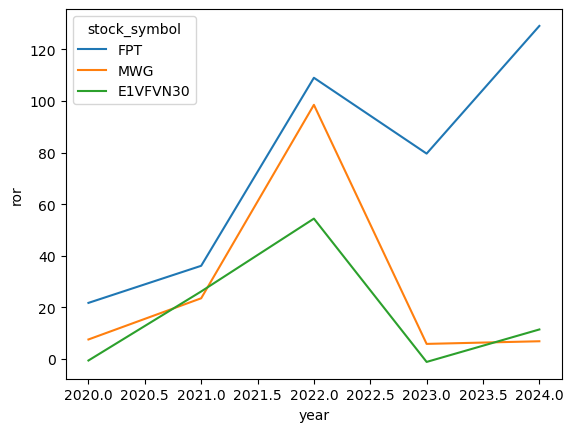

In [22]:
sns.lineplot(data=df, x='year', y='ror', hue='stock_symbol')

In [25]:
data_df = {
    'index': ['FPT_2020', 'FPT_2021', 'FPT_2022', 'FPT_2023', 'FPT_2024',
              'MWG_2020', 'MWG_2021', 'MWG_2022', 'MWG_2023', 'MWG_2024',
              'E1VFVN30_2020', 'E1VFVN30_2021', 'E1VFVN30_2022', 'E1VFVN30_2023', 'E1VFVN30_2024'],
    'stock_symbol': ['FPT', 'FPT', 'FPT', 'FPT', 'FPT', 
                     'MWG', 'MWG', 'MWG', 'MWG', 'MWG', 
                     'E1VFVN30', 'E1VFVN30', 'E1VFVN30', 'E1VFVN30', 'E1VFVN30'],
    'total_investment': [816.9, 1994.2, 2931.2, 4083.8, 5494.8, 
                         678.6, 2186.7, 2673.3, 4384.7, 5618.8, 
                         891.6, 1998.2, 3346.4, 4386.3, 5732.3],
    'current_shares': [400, 900, 1100, 1300, 1500, 
                       200, 700, 800, 1100, 1400, 
                       600, 1400, 2000, 2500, 3200],
    'current_equity': [994.0, 2713.5, 6127.0, 7334.6, 12591.0, 
                       729.4, 2699.9, 5307.2, 4637.6, 6000.4, 
                       885.6, 2520.0, 5166.0, 4332.5, 6384.0],
    'ror': [21.68, 36.07, 109.03, 79.60, 129.14, 
            7.49, 23.47, 98.53, 5.77, 6.79, 
            -0.67, 26.11, 54.37, -1.23, 11.37],
    'year': [2020, 2021, 2022, 2023, 2024, 
             2020, 2021, 2022, 2023, 2024, 
             2020, 2021, 2022, 2023, 2024]
}